# 12 — TTM Adaptation Experiment on NN5 Weekly

This notebook performs a focused Tiny Time Mixer (TTM) adaptation/configuration experiment on the `nn5_weekly` dataset from the Time Series PILE.

Dataset details:

- Domain: Retail
- Frequency: Weekly
- Short horizon: 4
- Long horizon: 8
- Horizon strategy: Metadata

The goal is to compare TTM default zero-shot behaviour against lightweight adapted/configured TTM settings.

This notebook evaluates whether changes to context length and loss preference improve TTM forecasting performance.

Important: this notebook is a lightweight adaptation/configuration experiment, not full foundation-model pretraining or large-scale fine-tuning.

## 1. Setup

Add the project root to the Python path and import the required libraries.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from src.data.dataset_loader import load_monash_dataset
from src.experiments.run_model_experiment import run_model_experiment

Importing plotly failed. Interactive plots will not work.


## 2. Experiment configuration

Define the dataset key, model name, and output directories for the TTM adaptation experiment.

The experiment is run on all available series for the selected dataset.

In [ ]:
DATASET_KEY = "nn5_weekly"
MODEL_NAME = "ttm"

OUTPUT_DIR = project_root / "results" / "raw_runs"
AGGREGATED_DIR = project_root / "results" / "aggregated"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AGGREGATED_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load dataset

Load the selected dataset using the shared Monash dataset loader.

The resolved dataset horizon is used to define short- and long-horizon forecasting tasks.

In [3]:
bundle = load_monash_dataset(DATASET_KEY)

DEFAULT_HORIZON = int(bundle["resolved_horizon"])

HORIZON_CONFIG = {
    "short": max(1, DEFAULT_HORIZON // 2),
    "long": DEFAULT_HORIZON,
}

dataset_info = {
    "dataset_key": bundle["dataset_key"],
    "domain": bundle["domain"],
    "frequency": bundle["normalized_frequency"],
    "default_horizon": bundle["resolved_horizon"],
    "horizon_strategy": bundle["horizon_strategy"],
    "short_horizon": HORIZON_CONFIG["short"],
    "long_horizon": HORIZON_CONFIG["long"],
    "num_series": len(bundle["records_df"]),
    "num_long_rows": len(bundle["long_df"]),
}

dataset_info

{'dataset_key': 'nn5_weekly',
 'domain': 'retail',
 'frequency': 'weekly',
 'default_horizon': 8,
 'horizon_strategy': 'metadata',
 'short_horizon': 4,
 'long_horizon': 8,
 'num_series': 111,
 'num_long_rows': 12543}

## 4. Define TTM adaptation configurations

Define the TTM configurations tested in this notebook.

The configurations compare default zero-shot behaviour against lightweight adapted settings using different context lengths and loss preferences.

In [4]:
TTM_CONFIGS = {
    "zero_shot_default": {
        "max_context": 512,
        "prefer_longer_context": True,
        "prefer_l1_loss": False,
    },

    "adapted_l1_loss": {
        "max_context": 512,
        "prefer_longer_context": True,
        "prefer_l1_loss": True,
    },

    "adapted_short_context": {
        "max_context": 256,
        "prefer_longer_context": True,
        "prefer_l1_loss": False,
    },

    "adapted_short_context_l1": {
        "max_context": 256,
        "prefer_longer_context": True,
        "prefer_l1_loss": True,
    },
}

TTM_CONFIGS

{'zero_shot_default': {'max_context': 512,
  'prefer_longer_context': True,
  'prefer_l1_loss': False},
 'adapted_l1_loss': {'max_context': 512,
  'prefer_longer_context': True,
  'prefer_l1_loss': True},
 'adapted_short_context': {'max_context': 256,
  'prefer_longer_context': True,
  'prefer_l1_loss': False},
 'adapted_short_context_l1': {'max_context': 256,
  'prefer_longer_context': True,
  'prefer_l1_loss': True}}

## 5. Run TTM adaptation experiments

Run each TTM configuration for both short- and long-horizon forecasting.

Each run is saved as raw per-series output for later analysis.

In [5]:
ttm_outputs = []

for config_name, model_params in TTM_CONFIGS.items():
    print(f"\n==============================")
    print(f"Running TTM config: {config_name}")
    print(model_params)
    print("==============================")

    for horizon_type, horizon in HORIZON_CONFIG.items():
        print(f"\nHorizon: {horizon_type} | h={horizon}")

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=MODEL_NAME,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type=config_name,
            output_dir=OUTPUT_DIR,
            model_params=model_params,
            series_limit=None,
            save_results=True,
        )

        result_df["ttm_config"] = config_name
        ttm_outputs.append(result_df)

print("All TTM adaptation experiments completed.")


Running TTM config: zero_shot_default
{'max_context': 512, 'prefer_longer_context': True, 'prefer_l1_loss': False}

Horizon: short | h=4


INFO:p-28465:t-8713740480:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-28465:t-8713740480:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 90-30-ft-r2.1.
INFO:p-28465:t-8713740480:get_model.py:get_model:[TTM] context_length = 90, prediction_length = 30
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set 

Saved: results/raw_runs/retail/nn5_weekly/ttm_short_h4_zero_shot_default.csv

Horizon: long | h=8


INFO:p-28465:t-8713740480:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 90-30-ft-r2.1.
INFO:p-28465:t-8713740480:get_model.py:get_model:[TTM] context_length = 90, prediction_length = 30
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device s

Saved: results/raw_runs/retail/nn5_weekly/ttm_long_h8_zero_shot_default.csv

Running TTM config: adapted_l1_loss
{'max_context': 512, 'prefer_longer_context': True, 'prefer_l1_loss': True}

Horizon: short | h=4


...

Saved: results/raw_runs/retail/nn5_weekly/ttm_long_h8_adapted_short_context.csv

Running TTM config: adapted_short_context_l1
{'max_context': 256, 'prefer_longer_context': True, 'prefer_l1_loss': True}

Horizon: short | h=4


Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set

Saved: results/raw_runs/retail/nn5_weekly/ttm_short_h4_adapted_short_context_l1.csv

Horizon: long | h=8


Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set

Saved: results/raw_runs/retail/nn5_weekly/ttm_long_h8_adapted_short_context_l1.csv
All TTM adaptation experiments completed.


## 6. Combine TTM adaptation outputs

Concatenate all TTM adaptation outputs into one DataFrame for analysis.

In [6]:
ttm_combined_df = pd.concat(ttm_outputs, ignore_index=True)

ttm_combined_df[
    [
        "dataset_key",
        "model",
        "horizon_type",
        "horizon",
        "series_id",
        "status",
        "error_message",
        "mae",
        "rmse",
        "smape",
        "ttm_config",
    ]
].head()

,dataset_key,model,horizon_type,horizon,series_id,status,error_message,mae,rmse,smape,ttm_config
0,nn5_weekly,ttm,short,4,T1,success,None,57.965725,60.682783,23.434342,zero_shot_default
1,nn5_weekly,ttm,short,4,T2,success,None,18.579048,19.828081,14.005054,zero_shot_default
2,nn5_weekly,ttm,short,4,T3,success,None,25.573626,26.153419,14.202807,zero_shot_default
3,nn5_weekly,ttm,short,4,T4,success,None,15.186499,16.185597,9.788548,zero_shot_default
4,nn5_weekly,ttm,short,4,T5,success,None,13.752683,14.811397,9.378716,zero_shot_default


## 7. Inspect failed TTM runs

Check whether any TTM configuration failed on specific series and inspect the error messages.

In [7]:
ttm_failed_df = ttm_combined_df[ttm_combined_df["status"] != "success"].copy()

ttm_failed_summary_df = (
    ttm_failed_df
    .groupby(["dataset_key", "model", "horizon_type", "ttm_config", "error_message"], as_index=False)
    .agg(n_failed=("series_id", "count"))
)

ttm_failed_summary_df

,dataset_key,model,horizon_type,ttm_config,error_message,n_failed


## 8. Summarise TTM accuracy

Aggregate successful TTM runs by horizon and configuration using MAE, RMSE, and sMAPE.

In [8]:
ttm_accuracy_df = (
    ttm_combined_df[ttm_combined_df["status"] == "success"]
    .groupby(
        ["dataset_key", "frequency", "model", "horizon_type", "horizon", "ttm_config"],
        as_index=False,
    )
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

ttm_accuracy_df

,dataset_key,frequency,model,horizon_type,horizon,ttm_config,n_series,mae,rmse,smape
0,nn5_weekly,weekly,ttm,long,8,adapted_l1_loss,111,21.372081,24.752703,16.533003
1,nn5_weekly,weekly,ttm,long,8,adapted_short_context_l1,111,21.372081,24.752703,16.533003
2,nn5_weekly,weekly,ttm,long,8,adapted_short_context,111,22.083139,25.312658,17.203020
3,nn5_weekly,weekly,ttm,long,8,zero_shot_default,111,22.083139,25.312658,17.203020
4,nn5_weekly,weekly,ttm,short,4,adapted_l1_loss,111,22.133493,25.105987,16.972032
5,nn5_weekly,weekly,ttm,short,4,adapted_short_context_l1,111,22.133493,25.105987,16.972032
6,nn5_weekly,weekly,ttm,short,4,adapted_short_context,111,22.648045,25.799568,17.511651
7,nn5_weekly,weekly,ttm,short,4,zero_shot_default,111,22.648045,25.799568,17.511651


## 9. Identify best TTM configuration per horizon

Select the TTM configuration with the lowest sMAPE for each forecast horizon.

In [9]:
best_ttm_idx = ttm_accuracy_df.groupby("horizon_type")["smape"].idxmin()

best_ttm_per_horizon_df = ttm_accuracy_df.loc[
    best_ttm_idx,
    ["horizon_type", "horizon", "ttm_config", "mae", "rmse", "smape", "n_series"]
].reset_index(drop=True)

best_ttm_per_horizon_df

,horizon_type,horizon,ttm_config,mae,rmse,smape,n_series
0,long,8,adapted_l1_loss,21.372081,24.752703,16.533003,111
1,short,4,adapted_l1_loss,22.133493,25.105987,16.972032,111


## 10. Compare TTM configurations against zero-shot default

Compare each adapted TTM configuration against the zero-shot/default TTM configuration.

Positive sMAPE improvement means the adapted configuration reduced sMAPE.

In [11]:
zero_shot_df = (
    ttm_accuracy_df[ttm_accuracy_df["ttm_config"] == "zero_shot_default"]
    .rename(
        columns={
            "mae": "mae_zero_shot",
            "rmse": "rmse_zero_shot",
            "smape": "smape_zero_shot",
        }
    )
)

adapted_df = (
    ttm_accuracy_df[ttm_accuracy_df["ttm_config"] != "zero_shot_default"]
    .rename(
        columns={
            "ttm_config": "ttm_config_adapted",
            "mae": "mae_adapted",
            "rmse": "rmse_adapted",
            "smape": "smape_adapted",
        }
    )
)

ttm_adaptation_comparison_df = adapted_df.merge(
    zero_shot_df[
        [
            "dataset_key",
            "model",
            "horizon_type",
            "horizon",
            "mae_zero_shot",
            "rmse_zero_shot",
            "smape_zero_shot",
        ]
    ],
    on=["dataset_key", "model", "horizon_type", "horizon"],
    how="left",
)

ttm_adaptation_comparison_df["smape_improvement"] = (
    ttm_adaptation_comparison_df["smape_zero_shot"]
    - ttm_adaptation_comparison_df["smape_adapted"]
)

ttm_adaptation_comparison_df = ttm_adaptation_comparison_df[
    [
        "dataset_key",
        "model",
        "horizon_type",
        "horizon",
        "ttm_config_adapted",
        "smape_zero_shot",
        "smape_adapted",
        "smape_improvement",
        "mae_zero_shot",
        "mae_adapted",
        "rmse_zero_shot",
        "rmse_adapted",
    ]
].sort_values(["horizon_type", "smape_improvement"], ascending=[True, False])

ttm_adaptation_comparison_df

,dataset_key,model,horizon_type,horizon,ttm_config_adapted,smape_zero_shot,smape_adapted,smape_improvement,mae_zero_shot,mae_adapted,rmse_zero_shot,rmse_adapted
0,nn5_weekly,ttm,long,8,adapted_l1_loss,17.203020,16.533003,0.670016,22.083139,21.372081,25.312658,24.752703
1,nn5_weekly,ttm,long,8,adapted_short_context_l1,17.203020,16.533003,0.670016,22.083139,21.372081,25.312658,24.752703
2,nn5_weekly,ttm,long,8,adapted_short_context,17.203020,17.203020,0.000000,22.083139,22.083139,25.312658,25.312658
3,nn5_weekly,ttm,short,4,adapted_l1_loss,17.511651,16.972032,0.539619,22.648045,22.133493,25.799568,25.105987
4,nn5_weekly,ttm,short,4,adapted_short_context_l1,17.511651,16.972032,0.539619,22.648045,22.133493,25.799568,25.105987
5,nn5_weekly,ttm,short,4,adapted_short_context,17.511651,17.511651,0.000000,22.648045,22.648045,25.799568,25.799568


## 11. Summarise TTM runtime and memory

Aggregate runtime and memory usage for each TTM configuration and forecast horizon.

In [10]:
ttm_runtime_df = (
    ttm_combined_df[ttm_combined_df["status"] == "success"]
    .groupby(["model", "horizon_type", "horizon", "ttm_config"], as_index=False)
    .agg(
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
        n_series=("series_id", "count"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

ttm_runtime_df

,model,horizon_type,horizon,ttm_config,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,n_series
0,ttm,long,8,zero_shot_default,9.407868e-07,0.343137,0.343142,2.057334,111
1,ttm,long,8,adapted_short_context_l1,1.226460e-06,0.509965,0.509972,0.405581,111
2,ttm,long,8,adapted_short_context,1.402589e-06,0.627488,0.627495,0.396727,111
3,ttm,long,8,adapted_l1_loss,1.467026e-06,0.760233,0.760240,2.410853,111
4,ttm,short,4,zero_shot_default,8.763494e-07,0.402602,0.402606,2.982474,111
5,ttm,short,4,adapted_l1_loss,1.056774e-06,0.472745,0.472750,2.127782,111
6,ttm,short,4,adapted_short_context_l1,1.316672e-06,0.644173,0.644180,0.405099,111
7,ttm,short,4,adapted_short_context,2.654823e-06,1.070538,1.070549,0.848899,111


## 12. Visualise TTM adaptation impact

Plot sMAPE by TTM configuration for each forecasting horizon.

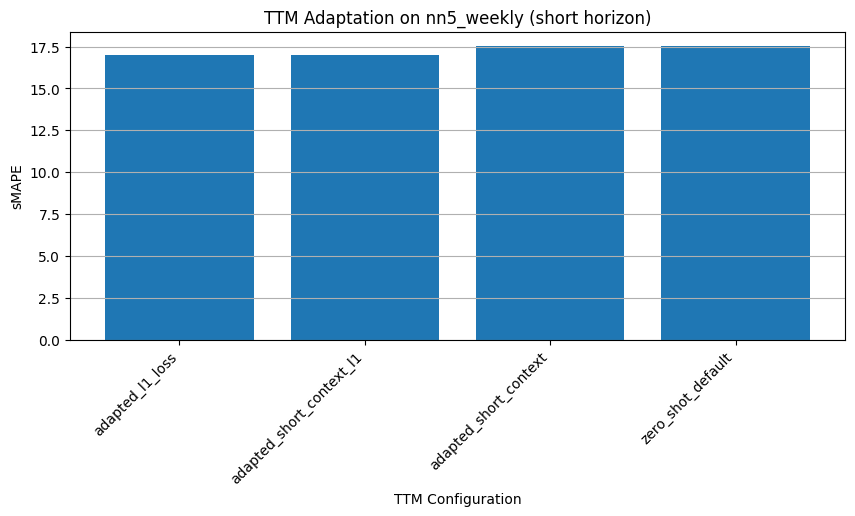

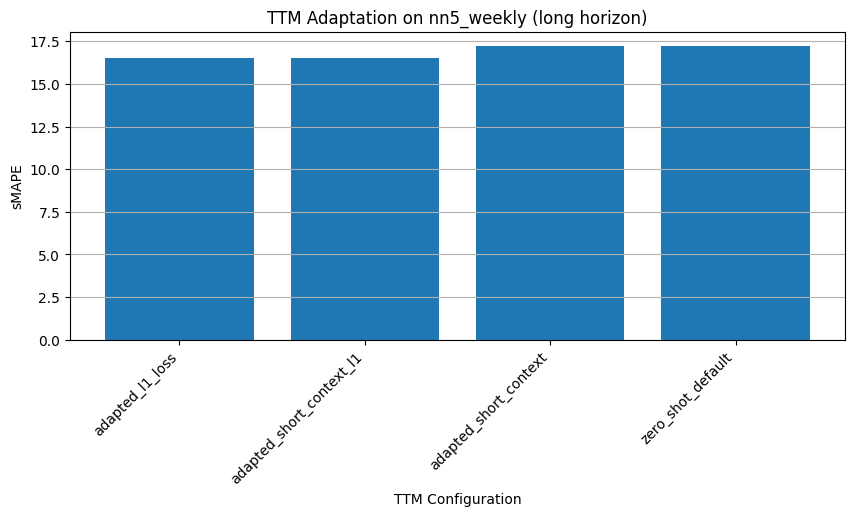

In [12]:
for horizon_type in HORIZON_CONFIG.keys():
    subset = ttm_accuracy_df[
        ttm_accuracy_df["horizon_type"] == horizon_type
    ].sort_values("smape")

    plt.figure(figsize=(10, 4))
    plt.bar(subset["ttm_config"], subset["smape"])
    plt.title(f"TTM Adaptation on {DATASET_KEY} ({horizon_type} horizon)")
    plt.xlabel("TTM Configuration")
    plt.ylabel("sMAPE")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.show()

## 13. Save TTM adaptation outputs

Save TTM adaptation accuracy, runtime, and comparison outputs for later analysis.

In [13]:
ttm_accuracy_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_ttm_adaptation_accuracy.csv",
    index=False,
)

best_ttm_per_horizon_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_ttm_adaptation_best_per_horizon.csv",
    index=False,
)

ttm_runtime_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_ttm_adaptation_runtime.csv",
    index=False,
)

ttm_adaptation_comparison_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_ttm_adaptation_comparison.csv",
    index=False,
)

ttm_failed_summary_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_ttm_adaptation_failures.csv",
    index=False,
)

print("Saved TTM adaptation outputs to:", AGGREGATED_DIR)

Saved TTM adaptation outputs to: results/aggregated


## 14. Adaptation findings checklist

Use the summaries above to inspect:

- whether any adapted TTM configuration improved over the zero-shot/default configuration,
- whether the improvement differed between short and long horizons,
- whether L1-loss preference improved sMAPE,
- whether shorter context improved or degraded performance,
- whether adaptation changed runtime or memory behaviour.

The final cross-dataset interpretation is performed in `14_final_analysis.ipynb`.